# ゆる言語学ラジオ YouTube動画分析

## プロジェクト概要
人気YouTubeチャンネル「ゆる言語学ラジオ」の全488本の動画を分析し、  
**どんなタイトル・テーマが再生数に影響するか**を統計・機械学習で検証した。

## 使用データ
- YouTube Data API v3で取得
- 対象：ゆる言語学ラジオ 全488本（2021年〜2026年）
- 取得項目：再生数・いいね数・コメント数・動画時間・投稿日時

## 分析の流れ
1. データ収集・概要把握
2. タイトルからの特徴量抽出（ルールベース）
3. 統計検定（Kruskal-Wallis + Dunn検定）
4. 機械学習モデル（RandomForest・アンサンブル）
5. 考察・結論

---
## 1. データ収集・概要把握

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Meiryo'

df = pd.read_csv('youtube_videos_features.csv', encoding='utf-8-sig')
print(f'動画数: {len(df)}本')
print(f'列: {list(df.columns)}')

動画数: 488本
列: ['video_id', 'title', 'published_at', 'views', 'likes', 'comments', 'duration', 'category', 'theme', 'emotion', 'difficulty', 'audience', 'title_type']


In [3]:
df[['views', 'likes', 'comments']].describe().round(0)

,views,likes,comments
count,488.0,488.0,488.0
mean,251769.0,4339.0,495.0
std,167180.0,2787.0,433.0
min,0.0,0.0,0.0
25%,149980.0,2742.0,280.0
50%,207024.0,3774.0,396.0
75%,302351.0,5004.0,588.0
max,1776223.0,37664.0,6260.0


**基本統計の読み方：**
- 平均再生数（251,854回）が中央値（207,041回）より大きい
- 一部の大ヒット動画（最大177万回）が平均を押し上げている
- 再生数の分布は右に歪んでいる（対数正規分布に近い）

In [4]:
# 再生数上位10本
df.sort_values('views', ascending=False)[['title', 'views']].head(10).reset_index(drop=True)

,title,views
0,「象は鼻が長い」の謎-日本語学者が100年戦う一大ミステリー #10,1776223
1,【3時間で全部学ぶ】音韻論の基礎から最適性理論まで【ちょいガチ言語学ラジオ】#275,1262732
2,ちょいガチ言語学ラジオ「意味論」#375,1170362
3,記述言語学者が語る、世界で日本語にしかない特徴は？【記述言語学者から見た言語2】#178,1007403
4,ゆる言語学ラジオ忘年会ライブ【流行語大賞決定&ひたすらエモい話】,878026
5,絵で物事を考える「視覚思考者」にはどんな世界が見えるのか？【ビジュアルシンカー1】#322,814534
6,徹底討論！ 「結論から喋る」は本当に正しいのか？ #373,788723
7,100年ずっと嫌われている「させていただく」。今も使われるのはなぜ？#237,773296
8,心は存在しない。【ビジュアルシンカー3】#324,737952
9,「論理的」は、地域によって違う #372,734616


---
## 2. 特徴量抽出（ルールベース分類）

タイトルのキーワードをもとに、以下の5つの特徴量をルールベースで付与した。  
APIは使わず、正規表現によるキーワードマッチングのみで分類。

| 特徴量 | 内容 | 例 |
|---|---|---|
| theme | 動画のテーマ（14カテゴリ） | クイズ・ゲーム、語源・語彙、心理・認知 |
| emotion | タイトルが誘う感情（9カテゴリ） | 驚き、疑問、知識欲 |
| difficulty | 難易度（3段階） | 初級、中級、上級 |
| audience | 想定視聴者（7カテゴリ） | 言語好き、雑学好き、読書好き |
| title_type | タイトルの型（10カテゴリ） | 質問型、クイズ型、断定型 |

In [5]:
# 各特徴量の分布確認
for col in ['theme', 'title_type', 'difficulty']:
    print(f'\n【{col}】')
    print(df[col].value_counts().to_string())


【theme】
theme
語源・語彙        141
その他           64
雑談・ライブ        53
クイズ・ゲーム       39
日本語文法         32
心理・認知         28
読書・学習         24
コミュニケーション     23
歴史・文化         22
方言・地域語        22
科学・自然         14
音声・音韻         14
意味・論理          8
文字・漢字          4

【title_type】
title_type
断定型       254
質問型       108
雑談型        35
クイズ型       35
解説型        23
謎解き型       13
ライブ型       12
検証型         7
ランキング型      1

【difficulty】
difficulty
中級    385
初級     85
上級     18


---
## 3. 統計分析

### 分析方針
- グループ間の再生数の差を検定するため、**Kruskal-Wallis検定**を使用
  - 理由：再生数は正規分布ではなく、グループのサイズも不均等なため
- 有意差があった場合、どのペアに差があるかを**Dunn検定（Bonferroni補正）**で確認
- サンプル数が10件未満のグループは検定から除外

### 3-1. テーマ別分析

In [6]:
theme_stats = df.groupby('theme')['views'].agg(['median', 'mean', 'count']).sort_values('median', ascending=False).round(0)
print(theme_stats.to_string())

             median      mean  count
theme                               
クイズ・ゲーム    343297.0  364951.0     39
科学・自然      293666.0  271213.0     14
コミュニケーション  285077.0  334714.0     23
心理・認知      279840.0  330434.0     28
意味・論理      224425.0  328715.0      8
文字・漢字      211642.0  224572.0      4
語源・語彙      207048.0  247086.0    141
雑談・ライブ     202952.0  232857.0     53
読書・学習      198318.0  242397.0     24
歴史・文化      195500.0  220355.0     22
方言・地域語     187754.0  214015.0     22
音声・音韻      166108.0  250934.0     14
日本語文法      158636.0  219819.0     32
その他        152434.0  175828.0     64


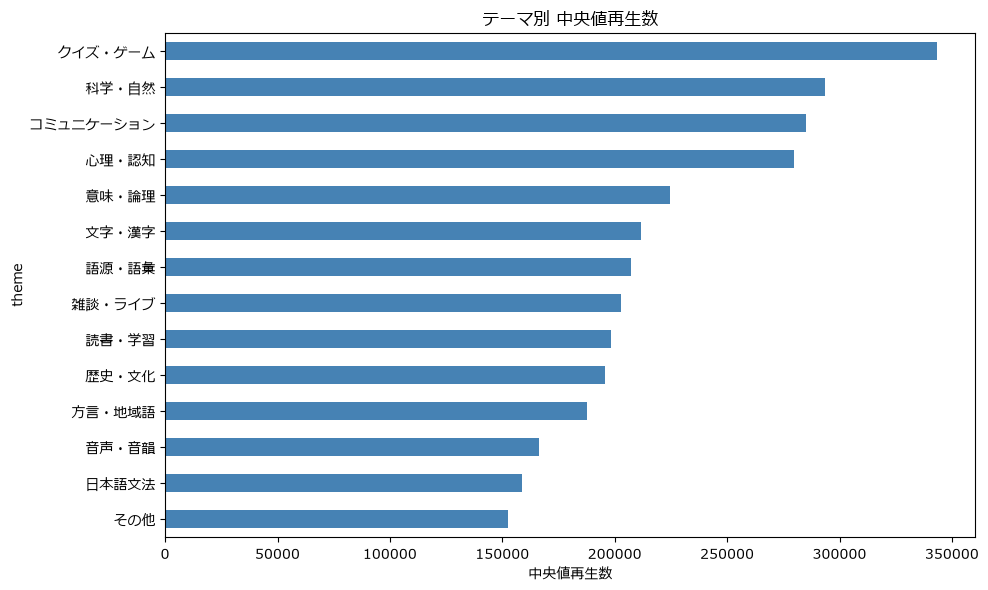

In [7]:
import os
os.makedirs("images", exist_ok=True)

df.groupby('theme')['views'].median().sort_values(ascending=True).plot(
    kind='barh', figsize=(10, 6), color='steelblue'
)
plt.xlabel('中央値再生数')
plt.title('テーマ別 中央値再生数')
plt.tight_layout()
plt.savefig('images/theme_views.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
from scipy import stats
import scikit_posthocs as sp

filtered_theme = df.groupby('theme').filter(lambda x: len(x) >= 10)
groups = [g['views'].values for _, g in filtered_theme.groupby('theme')]
stat, p = stats.kruskal(*groups)
print(f'Kruskal-Wallis: H={stat:.2f}, p={p:.2e}')

Kruskal-Wallis: H=70.95, p=8.05e-11


In [9]:
dunn_theme = sp.posthoc_dunn(filtered_theme, val_col='views', group_col='theme', p_adjust='bonferroni')

results = []
for i in dunn_theme.index:
    for j in dunn_theme.columns:
        if i < j and dunn_theme.loc[i, j] < 0.05:
            results.append({'テーマA': i, 'テーマB': j, 'p値': round(dunn_theme.loc[i, j], 4)})

sig_theme = pd.DataFrame(results).sort_values('p値')
print(sig_theme.to_string(index=False))

   テーマA      テーマB     p値
    その他   クイズ・ゲーム 0.0000
    その他     心理・認知 0.0001
クイズ・ゲーム     日本語文法 0.0001
クイズ・ゲーム     語源・語彙 0.0004
クイズ・ゲーム    雑談・ライブ 0.0012
    その他     語源・語彙 0.0016
    その他 コミュニケーション 0.0019
クイズ・ゲーム    方言・地域語 0.0041
クイズ・ゲーム     音声・音韻 0.0048
    その他     科学・自然 0.0235
クイズ・ゲーム     歴史・文化 0.0384


**テーマ分析のまとめ：**
- Kruskal-Wallis検定: H=70.95, p<0.001 → テーマ間に有意差あり
- **クイズ・ゲームテーマ**がその他・語源・語彙・日本語文法・方言などと比べて有意に高い
- 「その他」カテゴリが最も低く、クイズ・ゲームとの差が最も大きい（p=5.9×10⁻¹¹）

### 3-2. タイトル型別分析

In [10]:
title_stats = df.groupby('title_type')['views'].agg(['median', 'mean', 'count']).sort_values('median', ascending=False).round(0)
print(title_stats.to_string())

              median      mean  count
title_type                           
検証型         446660.0  408798.0      7
クイズ型        380045.0  372515.0     35
謎解き型        227539.0  349059.0     13
質問型         215653.0  250552.0    108
雑談型         206449.0  224137.0     35
断定型         188550.0  233897.0    254
解説型         187372.0  211895.0     23
ライブ型        181120.0  254801.0     12
ランキング型      180273.0  180273.0      1


In [11]:
filtered_type = df.groupby('title_type').filter(lambda x: len(x) >= 10)
groups = [g['views'].values for _, g in filtered_type.groupby('title_type')]
stat, p = stats.kruskal(*groups)
print(f'Kruskal-Wallis: H={stat:.2f}, p={p:.2e}')

dunn_type = sp.posthoc_dunn(filtered_type, val_col='views', group_col='title_type', p_adjust='bonferroni')
results = []
for i in dunn_type.index:
    for j in dunn_type.columns:
        if i < j and dunn_type.loc[i, j] < 0.05:
            results.append({'タイプA': i, 'タイプB': j, 'p値': round(dunn_type.loc[i, j], 4)})

print(pd.DataFrame(results).sort_values('p値').to_string(index=False))

Kruskal-Wallis: H=33.09, p=1.01e-05
タイプA タイプB     p値
クイズ型  断定型 0.0000
クイズ型  質問型 0.0007
クイズ型  解説型 0.0010
クイズ型  雑談型 0.0019
クイズ型 ライブ型 0.0174


**タイトル型分析のまとめ：**
- Kruskal-Wallis検定: H=33.09, p<0.001 → タイトル型間に有意差あり
- **クイズ型**が断定型・質問型・解説型・雑談型と比べて有意に高い
- 断定型（254本）は最も本数が多いが、再生数は中位

### 3-3. その他の特徴量分析（emotion / difficulty / audience）

In [12]:
for col in ['emotion', 'difficulty', 'audience']:
    print(f"\n{'='*40}")
    print(f'【{col}】')
    filtered = df.groupby(col).filter(lambda x: len(x) >= 5)
    groups = [g['views'].values for _, g in filtered.groupby(col)]
    stat, p = stats.kruskal(*groups)
    print(f'Kruskal-Wallis: H={stat:.2f}, p={p:.4f}')
    
    if p < 0.05:
        dunn = sp.posthoc_dunn(filtered, val_col='views', group_col=col, p_adjust='bonferroni')
        results = []
        for i in dunn.index:
            for j in dunn.columns:
                if i < j and dunn.loc[i, j] < 0.05:
                    results.append({'グループA': i, 'グループB': j, 'p値': round(dunn.loc[i, j], 4)})
        if results:
            print(pd.DataFrame(results).sort_values('p値').to_string(index=False))
        else:
            print('有意差のあるペアなし')


【emotion】
Kruskal-Wallis: H=20.26, p=0.0050
有意差のあるペアなし

【difficulty】
Kruskal-Wallis: H=12.59, p=0.0018
グループA グループB     p値
   中級    初級 0.0017

【audience】
Kruskal-Wallis: H=25.33, p=0.0000
グループA グループB     p値
 言語好き  雑学好き 0.0000
 読書好き  雑学好き 0.0039


**emotion / difficulty / audience のまとめ：**

| 特徴量 | 結果 | 補足 |
|---|---|---|
| emotion | 全体で有意差あり（p=0.005）、ペアワイズでは有意なし | サンプル数が少なく検出力が不足 |
| difficulty | 初級 > 中級（p=0.0017）| 初級にクイズ・雑談が含まれるため |
| audience | 雑学好き > 言語好き・読書好き（p<0.01）| 雑学好き向け（クイズ系）が高い |

難易度・ターゲット層も再生数と関係するが、テーマ・タイトル型ほど明確ではない。

---
## 4. 機械学習モデル

### 目的変数
再生数が中央値以上かどうかの二値分類（popular: 0/1）

### 使用特徴量
5つの特徴量をダミー変数化（計40列）

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

df['popular'] = (df['views'] >= df['views'].median()).astype(int)

features = ['theme', 'emotion', 'difficulty', 'audience', 'title_type']
X = pd.get_dummies(df[features])
y = df['popular']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.76      0.45      0.57        64
           1       0.42      0.74      0.53        34

    accuracy                           0.55        98
   macro avg       0.59      0.59      0.55        98
weighted avg       0.64      0.55      0.56        98



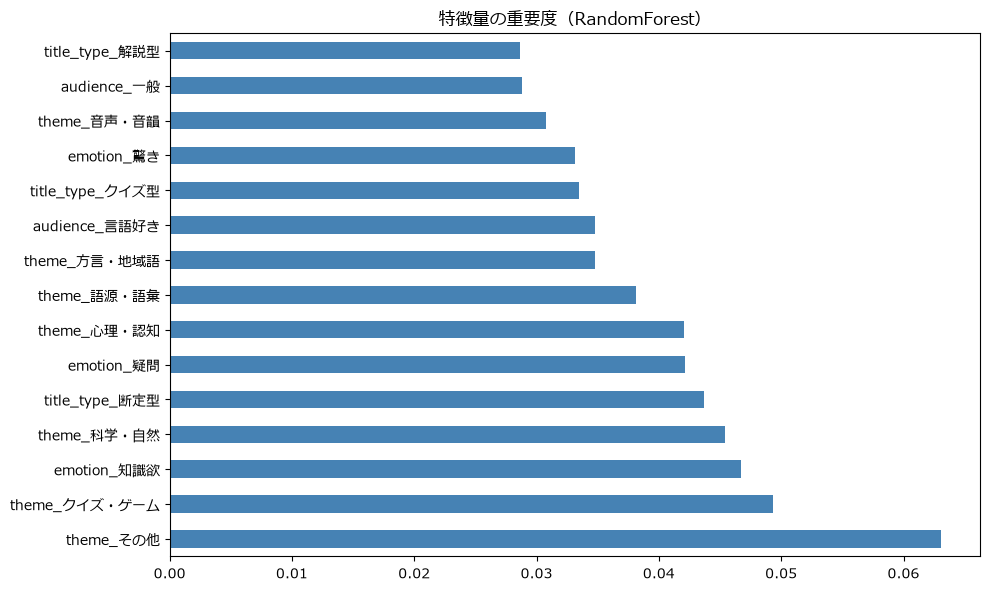

In [14]:
# 特徴量重要度
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(15).plot(
    kind='barh', figsize=(10, 6), color='steelblue'
)
plt.title('特徴量の重要度（RandomForest）')
plt.tight_layout()
plt.show()

**MLモデルの結果：accuracy = 55%**

ランダム予測（50%）と比べてわずか5%の改善にとどまった。

特徴量を追加（投稿曜日・シリーズ番号・タイトル文字数）しても59%止まりで、  
LightGBM・CatBoostとのアンサンブルでも同様の結果だった。

---
## 5. 考察・結論

### なぜMLモデルの精度が低かったのか

**1. 特徴量の限界**  
使用した特徴量はすべてタイトルのキーワードから作ったルールベースの分類であり、  
コンテンツの本質的な面白さを捉えられていない。

**2. 外部要因の影響が大きい**  
再生数はチャンネルの成長・投稿タイミング・サムネイルなどにも強く依存する。  
実際、シリーズ番号（チャンネルの成長時期）が最重要特徴量になったことがその証拠。

**3. データ量の不足**  
488件は機械学習には少なく、過学習しやすい環境だった。

### 統計分析から得られた実用的な知見

MLモデルの予測精度は低かったが、統計検定により以下の知見が得られた：

| 知見 | 統計的根拠 |
|---|---|
| クイズ・ゲームテーマは他テーマより再生数が有意に高い | Dunn検定 p<0.001 |
| クイズ型タイトルは断定型・質問型より有意に高い | Dunn検定 p<0.001 |
| テーマの影響（H=70.95）はタイトル型（H=33.09）より大きい | Kruskal-Wallis |

### 結論

> タイトル特徴量だけでは再生数の予測は困難だが、  
> **クイズ・ゲーム系のテーマ・タイトルが統計的に高い再生数と関連する**ことが示された。  
> ただし、これをそのまま活用（クイズ動画ばかり作る）するとチャンネルの世界観が崩れる可能性があり、  
> データ分析の結果は「参考」として活用するべきである。